In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# --- IMPORTING FROM OTHER FILES
import sys
import os

# Add path to the package: relativistic_dof
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))
from parameter_dependence import ParametersAxionMassDependence
from second_interpolation import get_process

## Configure the Setup and Select the Production Channel

In this section, we choose the axion production process to analyze and set flags that control output behavior (e.g., saving plots or data). Additional parameters:

- `file_number`: We define it, to select the process:
  - $0$ : Electron scattering
  - $1$ : Muon decay
  - $2$ : Muon scattering
  - $3$ : Tau decay
  - $4$ : Tau scattering

In [3]:
# --- SELECT FILE, SET FLAGS (MANUAL) ---
file_number = 2

In [4]:
# --- Define process labels and corresponding filenames for selected production channel ---
title_arr = [
    r"$\bf e$ scattering",
    r"$\bf \mu$ decay", 
    r"$\bf \mu$ scattering",
    r"$\bf \tau$ decay", 
    r"$\bf \tau$ scattering"
]
filename_dist_arr = [
    "Distributions_fa_e_scat.dat", 
    "Distributions_fa_mu_dec.dat", 
    "Distributions_fa_mu_scat.dat",
    "Distributions_fa_tau_dec_extended.dat", #"Distributions_fa_tau_dec.dat" 
    "Distributions_fa_tau_scat_extended.dat", #"Distributions_fa_tau_scat.dat"
]
filename_save_plots_arr = [
    "electron_scattering", 
    "muon_decay", 
    "muon_scattering", 
    "tau_decay", 
    "tau_scattering"
]
####################################################################################################################
filename_dist = f"../../data-new/{filename_dist_arr[file_number]}"
# filename_dist = f"/home/krzysztof/Workspace/Master-coding/real_distribution/data-new/{filename_dist_arr[file_number]}"
filename_save_plots = f"{filename_save_plots_arr[file_number]}"

In [5]:
# --- Initialize CLASS, which deals with mass dependence
parameterDependence = ParametersAxionMassDependence(filename_save_plots, filename_dist)

# --- DISTRIBUTION: f(q)*q^3 ---
distribution = "f(q)_q2"  # "f(q)_q2"
parameterDependence.fit_all_distributions(dist=distribution)

# Set bounds for log(m_a)
m_end, m_start = parameterDependence.get_max_min_ma()
log_m_start = np.log(m_start)
log_m_end = np.log(m_end)
log_m_arr_set = np.linspace(log_m_start, log_m_end, 600)

# --- Interpolation ---
interpolated_A_value = parameterDependence.get_interpolated_function(dist=distribution, parameter="A")(log_m_arr_set)
interpolated_b_value = parameterDependence.get_interpolated_function(dist=distribution, parameter="b")(log_m_arr_set)
interpolated_mu_value = parameterDependence.get_interpolated_function(dist=distribution, parameter="mu")(log_m_arr_set)

# --- Base Data ---
m_arr_input = parameterDependence.get_axion_masses()
log_m_arr_input = np.log(m_arr_input)
fit_parameter = parameterDependence.get_fit_parameters(dist=distribution)

In [6]:
# --- Function Fitting: A(log(m_a)), b(log(m_a)), and μ(log(m_a)) ---
# polynomial
parameterDependence.compute_polynomial_fit(dist=distribution, poly_order=13)

# function fit
# parameterDependence.switch_fitting_function("A", "piecewise")
# parameterDependence.switch_fitting_function("b", "b_function")
# parameterDependence.switch_fitting_function("mu", "exp_decay")
# parameterDependence.compute_functional_fit(dist=distribution)

Polynomial fit coefficients for A: [ 1.56559417e-05  1.44665366e-04  3.18263373e-04 -8.18634807e-04
 -3.82284830e-03 -1.85593688e-04  1.52036557e-02  1.00049709e-02
 -3.14890853e-02 -2.52676918e-02  4.90630469e-02  2.36040527e-02
 -1.19228329e-01  1.11060238e+00]
Polynomial fit coefficients for b: [ 4.70494646e-05  3.70545103e-04  4.38570979e-04 -3.17235523e-03
 -7.20565091e-03  1.15323140e-02  3.47399996e-02 -3.25267254e-02
 -9.78207471e-02  1.12940592e-01  2.30144764e-01 -5.63877245e-01
  3.78121904e-01 -1.31034922e-01]
Polynomial fit coefficients for μ: [ 1.80703572e-03  1.15221881e-02  4.68544104e-03 -9.57267829e-02
 -1.21018225e-01  2.92556553e-01  4.87289678e-01 -5.42438144e-01
 -4.47287960e-01 -2.07847459e-01  1.76562466e+00 -2.14455439e+00
  1.26903374e+00 -2.87998071e+00]


## Plots: $A(log(m_a))$, $b(log(m_a))$, and $μ(log(m_a))$

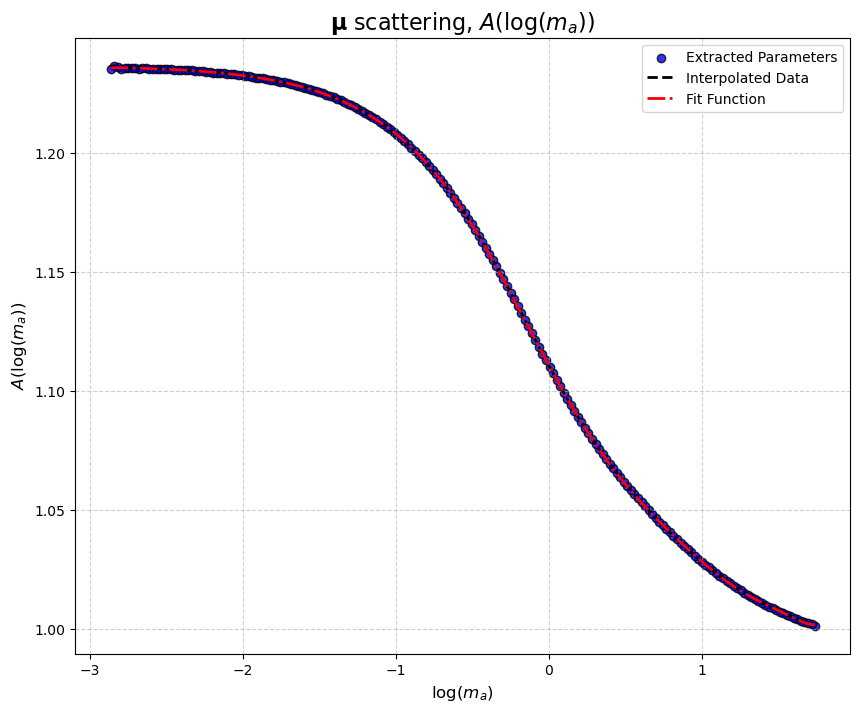

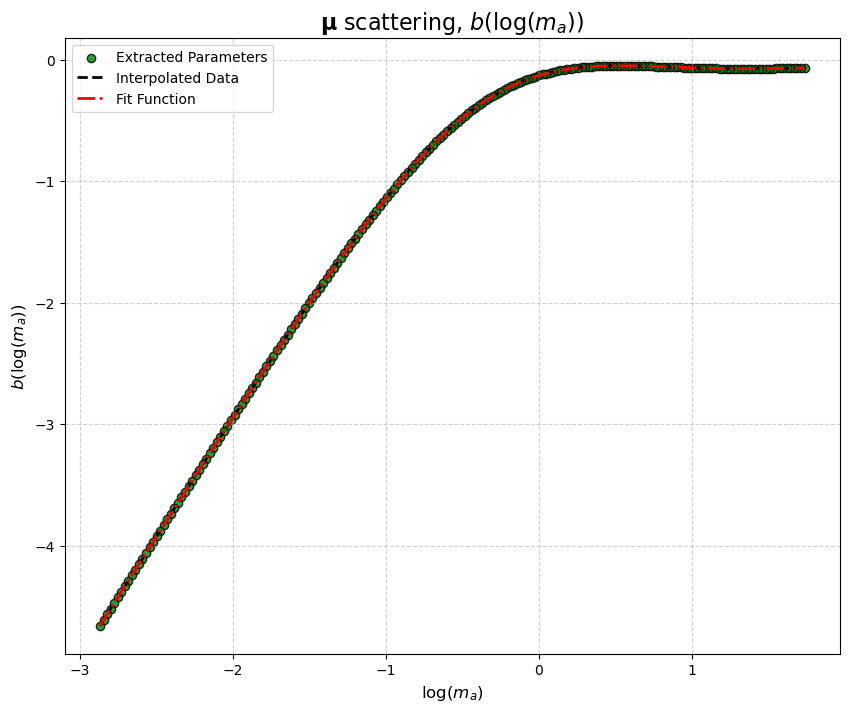

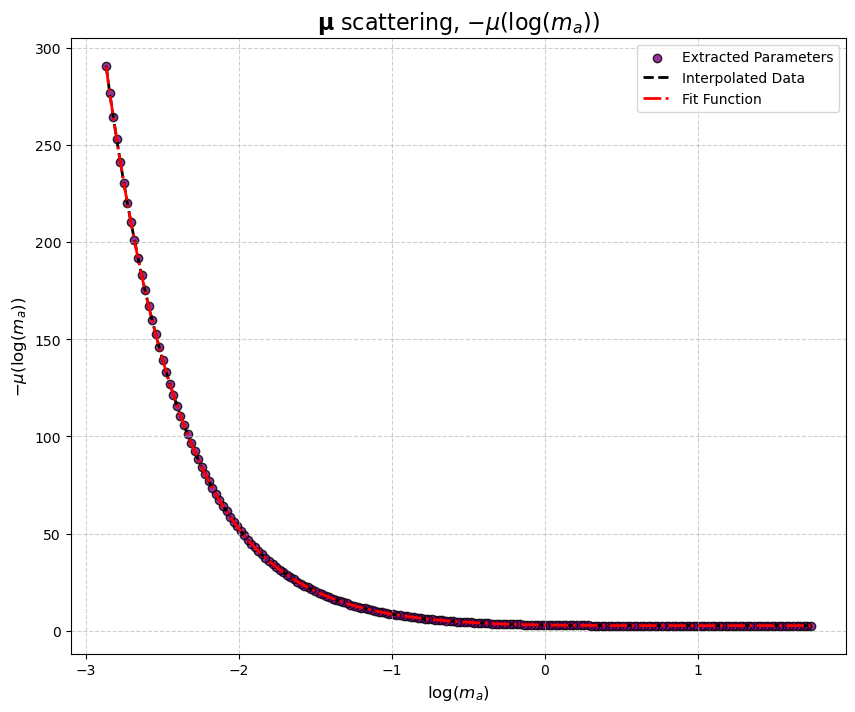

In [7]:
# --- PLOT EACH PARAMETER SEPARATELY ---
name_of_parameters = ["A", "b", "mu"]
interpolated_param = [interpolated_A_value, interpolated_b_value, interpolated_mu_value]
points_param = [fit_parameter['A'], fit_parameter['b'], fit_parameter['mu']]
titles = [r"$A(\log(m_{a}))$", r"$b(\log(m_{a}))$", r"$-\mu(\log(m_{a}))$"]

colors = ['blue', 'green', 'purple']  # Different colors for better distinction

for i in range(3):
    plt.figure(figsize=(10, 8))
    plt.title(f"{title_arr[file_number]}, {titles[i]}", fontsize=16)

    # Scatter plot of extracted parameter values
    if name_of_parameters[i] == "mu":
        plt.scatter(log_m_arr_input, (-1)*points_param[i],
                    color=colors[i], marker='o', edgecolors='black',
                    alpha=0.8, label='Extracted Parameters')
    else:
        plt.scatter(log_m_arr_input, points_param[i],
                    color=colors[i], marker='o', edgecolors='black',
                    alpha=0.8, label='Extracted Parameters')


    # Plot interpolation of extracted values
    if name_of_parameters[i] == "mu":
        plt.plot(log_m_arr_set, (-1)*interpolated_param[i],
                 linestyle='--', linewidth=2, color='black',
                 label='Interpolated Data')
    else:
        plt.plot(log_m_arr_set, interpolated_param[i],
                 linestyle='--', linewidth=2, color='black',
                 label='Interpolated Data')


    # Plot fitted function for the parameter
    if name_of_parameters[i] == "mu":
        plt.plot(log_m_arr_set, (-1)*parameterDependence.get_fitted_parameter_value(name_of_parameters[i],
                                                                                    log_m_arr_set,
                                                                                  "test_polynomial"),  # test_polynomial, test_fit
                 linestyle='-.', linewidth=2, color='red',
                 label='Fit Function')
    else:
        plt.plot(log_m_arr_set, parameterDependence.get_fitted_parameter_value(name_of_parameters[i],
                                                                               log_m_arr_set,
                                                                             "test_polynomial"),  # test_polynomial, test_fit
                 linestyle='-.', linewidth=2, color='red',
                 label='Fit Function')

    # Labels and formatting
    plt.xlabel(r'$\log(m_{a})$', fontsize=12)
    plt.ylabel(titles[i], fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=10)

    # Set log scale only for the y-axis of μ(m_a)
    # if name_of_parameters[i] == "mu":
    #     plt.yscale("log")

    # Show each plot separately
    plt.show()

In [8]:
for i in range(0, len(m_arr_input)):
    ma = m_arr_input[i]
    val_parameter_A = parameterDependence.get_fitted_parameter_value("A", np.log(ma), "test_polynomial")  # test_polynomial, test_fit
    val_parameter_b = parameterDependence.get_fitted_parameter_value("b", np.log(ma), "test_polynomial")
    val_parameter_mu = parameterDependence.get_fitted_parameter_value("mu", np.log(ma), "test_polynomial")

    print("--------------------------------------------------------------------------------------------------------")
    print(f"input A: {fit_parameter['A'][i]}, fitted A: {val_parameter_A}")
    print(f"input b: {fit_parameter['b'][i]}, fitted b: {val_parameter_b}")
    print(f"input mu: {fit_parameter['mu'][i]}, fitted mu: {val_parameter_mu}")


--------------------------------------------------------------------------------------------------------
input A: 1.001225559603036, fitted A: 1.0015832186046802
input b: -0.06764781526960273, fitted b: -0.06696829993218614
input mu: -2.5481611315429764, fitted mu: -2.52094497512164
--------------------------------------------------------------------------------------------------------
input A: 1.0017465919754347, fitted A: 1.0017215378900914
input b: -0.06832742300456583, fitted b: -0.06839947792088295
input mu: -2.551382964367827, fitted mu: -2.550787231028057
--------------------------------------------------------------------------------------------------------
input A: 1.0022647045073259, fitted A: 1.002068832244381
input b: -0.06909210402806983, fitted b: -0.06943877229746115
input mu: -2.554819357682447, fitted mu: -2.567806237117664
--------------------------------------------------------------------------------------------------------
input A: 1.0028208599344843, fitted A: 1.0